# Individuell uppgift – Hälsostudie (Del 1)

I denna notebook gör jag en grundläggande analys av ett hälsodata. 
Jag beräknar beskrivande statistik, skapar visualiseringar, gör en simulering, 
beräknar ett konfidensintervall och testar en hypotes om blodtryck hos rökare och icke rökare.


In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

np.random.seed(42)

df = pd.read_csv("data/health_study_dataset.csv")

df.head()


,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


In [88]:
cols = ["age", "weight", "height", "systolic_bp", "cholesterol"]    

summary_stats = df[cols].agg(["mean", "median", "min", "max"]).round(2) 

summary_stats

,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


### Statistik

Här har jag beräknat medelvärde, median, min- och maxvärde för ålder, vikt, längd, systoliskt blodtryck och kolesterol.

- Medelåldern i studien är cirka **49 år** och medianen är **50 år**.
- Medelvikten är ungefär **73 kg** och längden cirka **172 cm**.
- Det systoliska blodtrycket ligger i snitt runt **149 mmHg**.
- Kolesterolnivån har ett medelvärde på ungefär **4,9 mmol/L**.

Min och maxvärdena visar spridningen i datan, t.ex. att deltagarnas ålder ligger mellan 18 och 90 år.


# Graf nr 1

### Histogram över systoliskt blodtryck

Histogrammet visar fördelningen av deltagarnas systoliska blodtryck. De flesta deltagarna ligger runt
**140–155 mmHg** vilket är något förhöjt. Vi ser också att det finns en viss spridning med både lägre
och högre värden men majoriteten ligger kring mitten av histogrammet.


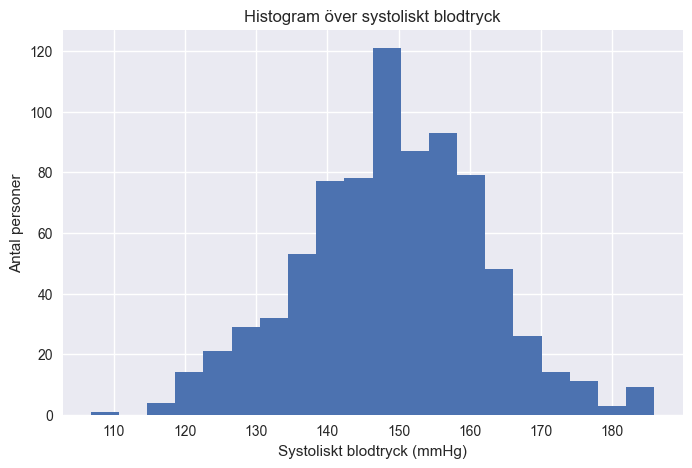

In [89]:
plt.figure(figsize=(8,5))
plt.hist(df["systolic_bp"], bins=20)
plt.xlabel("Systoliskt blodtryck (mmHg)")
plt.ylabel("Antal personer")
plt.title("Histogram över systoliskt blodtryck")
plt.show()


# Graf nr 2

### Boxplot över vikt per kön

Boxploten visar viktfördelningen för män och kvinnor. Vi ser att män i genomsnitt väger mer än kvinnor,
vilket är väntat. Diagrammet visar också spridningen inom grupperna, inklusive eventuella extremvärden.


<Figure size 800x500 with 0 Axes>

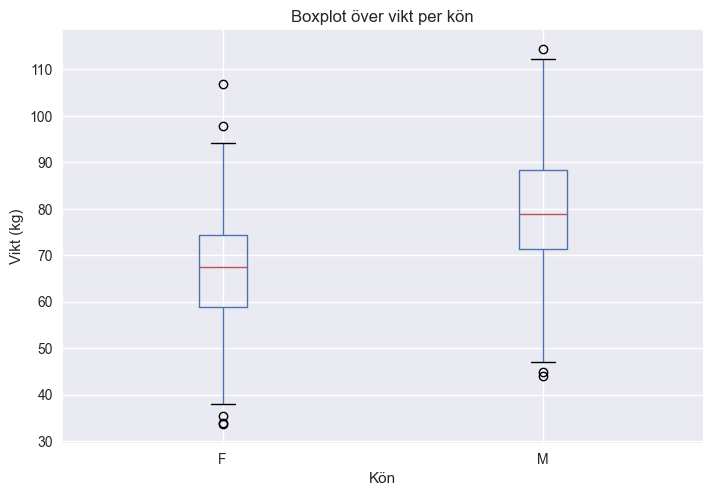

In [90]:
plt.figure(figsize=(8,5))
df.boxplot(column="weight", by="sex")
plt.title("Boxplot över vikt per kön")
plt.suptitle("") 
plt.xlabel("Kön")
plt.ylabel("Vikt (kg)")
plt.show()


# Graf nr 3

### Stapeldiagram över rökare och icke-rökare

Stapeldiagrammet visar hur många personer i studien som röker respektive inte röker.
Det är tydligt att majoriteten av deltagarna inte är rökare, vilket ger en bra bild av
studiepopulationens livsstil.


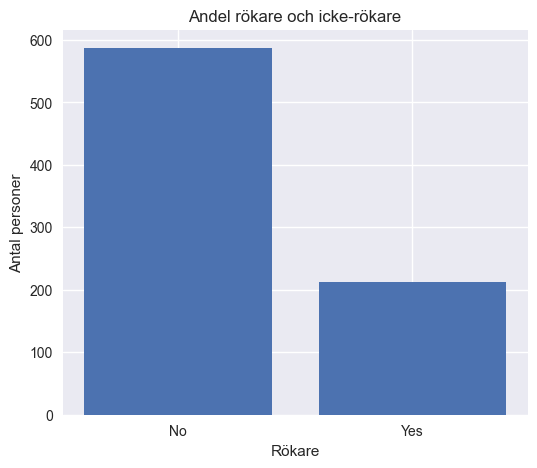

In [91]:
smoker_counts = df["smoker"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(smoker_counts.index, smoker_counts.values)
plt.title("Andel rökare och icke-rökare")
plt.xlabel("Rökare")
plt.ylabel("Antal personer")
plt.show()


In [92]:
real_disease_rate = df["disease"].mean() 
real_disease_rate

print("Verklig andel sjukdom:", round(real_disease_rate * 100, 2), "%")

simulated = np.random.choice([0, 1], size=1000, p=[1-real_disease_rate, real_disease_rate])

simulated_rate = simulated.mean()
simulated_rate

print("Simulerad andel sjukdom (1000 personer):", round(simulated_rate * 100, 2), "%")

Verklig andel sjukdom: 5.88 %
Simulerad andel sjukdom (1000 personer): 5.6 %


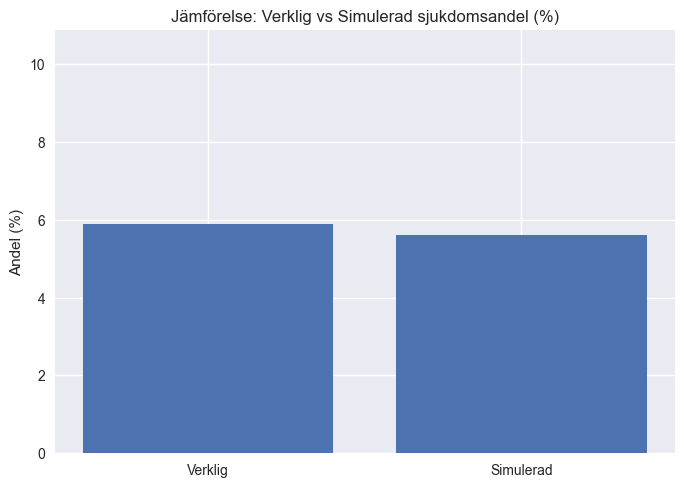

In [93]:
plt.bar(["Verklig", "Simulerad"], [real_disease_rate*100, simulated_rate*100])
plt.ylabel("Andel (%)")
plt.title("Jämförelse: Verklig vs Simulerad sjukdomsandel (%)")
plt.ylim(0, max(real_disease_rate, simulated_rate)*100 + 5)
plt.show()


### Simulering av sjukdomsförekomst

Först beräknade jag den verkliga andelen personer med sjukdomen i datasetet. Sedan simulerade jag
1000 nya personer med samma sannolikhet för sjukdom genom att använda numpy.random.choice.

Syftet är att se om simuleringen ger ett liknande resultat som den verkliga datan. Resultatet blev
att de två andelarna ligger nära varandra, vilket är rimligt eftersom simuleringen bygger på samma
sannolikhet som i datasetet.


In [94]:
bp = df["systolic_bp"]

mean_bp = bp.mean()
std_bp = bp.std()
n = len(bp)

z = 1.95     
margin = z * std_bp / np.sqrt(n)

ci_lower = mean_bp - margin
ci_upper = mean_bp + margin

ci_lower, ci_upper

int(round(ci_lower)), int(round(ci_upper))


(148, 150)

### Konfidensintervall för systoliskt blodtryck

Jag beräknade ett 95% konfidensintervall för medelvärdet av systoliskt blodtryck med hjälp av 
normalapproximationen. Formeln bygger på Central Limit Theorem, som innebär att medelvärdet 
av ett stort stickprov är ungefär normalfördelat.

Konfidensintervallet visar det intervall där det sanna medelvärdet för blodtryck i populationen
troligen ligger. Intervallet blev:

**[148, 150]**

Det betyder att vi med 95% säkerhet kan säga att det sanna medelvärdet av systoliskt blodtryck
i populationen ligger inom detta intervall.


In [95]:
from scipy.stats import ttest_ind

smokers = df[df["smoker"] == "Yes"]["systolic_bp"]  
nonsmokers = df[df["smoker"] == "No"]["systolic_bp"]

t_stat, p_value_two_sided = ttest_ind(smokers, nonsmokers, equal_var=False)    # T-test

p_value_one_sided = p_value_two_sided / 2

t_stat, p_value_one_sided

print(f"T-statistik: {t_stat:.3f}")
print(f"P-värde (one-sided): {p_value_one_sided:.4f}")



T-statistik: 0.450
P-värde (one-sided): 0.3264


### Hypotesprövning: Har rökare högre blodtryck?

Jag gjorde ett t-test för att undersöka om rökare har högre medelvärde på systoliskt blodtryck än
icke rökare. 

Hypoteserna är:

- **H₀:** Rökare har inte högre blodtryck än icke rökare.
- **H₁:** Rökare har högre blodtryck än icke rökare.

Jag använde ett envägs t-test (one-sided). Resultatet på p-värdet:

**p = 0,326**

Om p-värdet är lägre än 0.05 betyder det att vi kan förkasta nollhypotesen och säga att rökare har
signifikant högre blodtryck än icke rökare.

Om p-värdet är större än 0.05 finns det inte tillräckligt med bevis i datan för att säga att rökare
har högre blodtryck.
